# 03. Classical Model and SHAP

Train a gradient boosting classifier on the stress regime task, then explain its predictions with SHAP.

The train/test split is chronological, not shuffled, since this is time series data and shuffling would leak future information into training. Features are already lagged by one day relative to the label (see `features.py`), so this is a genuine one-day-ahead prediction task rather than same-day lookup.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from classical_model import train_baseline_model, evaluate_model, compute_shap_values, RANDOM_STATE

## Load features and split chronologically

In [2]:
features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)

X = features.drop(columns=['stress'])
y = features['stress']

# Chronological split: no shuffling, test set is the most recent 25%
split_idx = int(len(features) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} samples, {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test:  {X_test.shape[0]} samples, {X_test.index.min().date()} to {X_test.index.max().date()}")
print(f"\nTrain stress rate: {y_train.mean():.3f}")
print(f"Test stress rate:  {y_test.mean():.3f}")

Train: 1588 samples, 2018-02-01 to 2024-05-23
Test:  530 samples, 2024-05-24 to 2026-07-10

Train stress rate: 0.306
Test stress rate:  0.083


## Train baseline model

In [3]:
model = train_baseline_model(X_train, y_train)
print("Model trained: GradientBoostingClassifier")

Model trained: GradientBoostingClassifier


## Evaluate on test set

In [4]:
results = evaluate_model(model, X_test, y_test)
print(f"AUC:   {results['auc']:.4f}")
print(f"Brier: {results['brier']:.4f}")

AUC:   0.9879
Brier: 0.0153


In [5]:
results_df = pd.DataFrame([{'model': 'classical_gradient_boosting', 'auc': results['auc'], 'brier': results['brier']}])
results_df.to_csv('../data/processed/classical_results.csv', index=False)
print("Saved data/processed/classical_results.csv")

Saved data/processed/classical_results.csv


## SHAP explanation

Background dataset has 530 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=530 when initializing the masker.


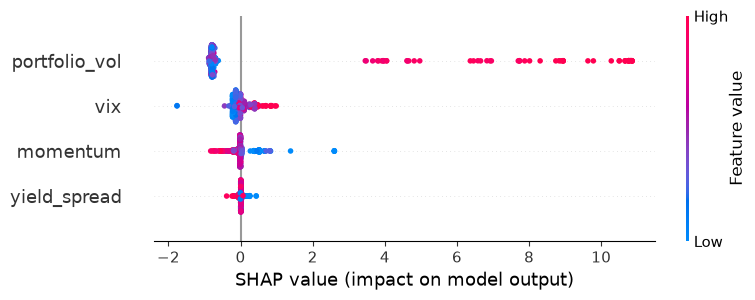

Saved figure: figures/03_shap_summary.png


In [6]:
shap_values = compute_shap_values(model, X_test)

fig = plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../figures/03_shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/03_shap_summary.png")

## Feature importance ranking

In [7]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)
print("Feature importance (mean |SHAP value|):")
print(importance)

Feature importance (mean |SHAP value|):
portfolio_vol    1.540450
vix              0.160490
momentum         0.141211
yield_spread     0.025885
dtype: float64


**Interpretation**: `portfolio_vol` dominates by a wide margin, which makes sense given
volatility clustering: yesterday's realized volatility is the single strongest predictor of
today's regime. `vix` and `momentum` contribute a secondary, complementary signal.
`yield_spread` carries the least weight, roughly an order of magnitude below the top feature.
All 4 features still carry non-zero importance, so all 4 are kept for the quantum classifier
next, ranked by their SHAP contribution.

## Selected features for quantum model

The quantum classifier uses `n_qubits=4`, so we take all 4 available features, ranked by
SHAP importance.

In [8]:
selected_features = list(importance.index)
print(f"Selected features (ranked): {selected_features}")

Selected features (ranked): ['portfolio_vol', 'vix', 'momentum', 'yield_spread']
